<a href="https://colab.research.google.com/github/Teresa-Shah/5610_Assignments/blob/main/Assignment-3/Assignment-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Chemical Applications of Machine Learning (CHEM 4930/5610) - Spring 2026

### Assignment 3 - Deadline 2/27/2026
Points 10

#### General Comments
All figures and graph should have approriate labels on the two axis, and should include a legend with appropriate labels of the different plots.

The notebook should be return in working format. That is, I should be able to reset all the output and re-run all the cells and get the same results as you obtained.

**You should start by saving a copy of the notebook to your Google Drive so you preserve all changes.**

**Please add your name as a suffix to the filname**

**Student Name**: Add your name here

**AI usage statement:**
Here you should give a statement about any usage of AI tools to assist you with the coding.

### Task 1 - 10 points

In this task, we will consider data from this paper:
- Enhancing Permeability Prediction of Heterobifunctional Degraders Using Machine Learning and Metadynamics-Informed 3D Molecular Descriptors - [DOI:10.1021/acs.jcim.5c01600](https://doi.org/10.1021/acs.jcim.5c01600)

Where the authors consider the Permeability of so-called PROTAC compounds that are large and flexible molecules used in Targeted Protein Degradation.

All the dataset used in the paper, and the code use to obtain the results are given in this following Github repository:
- https://github.com/brykimjh/degrader-permeability-ml3d-metaD  

The specfic dataset that we use 32 PROTAC compounds with measured passive permeability (given in nm/s) and includes 17 2D features calculated by RDKit (see [here](https://github.com/brykimjh/degrader-permeability-ml3d-metaD/blob/main/data/calculate_2d_properties.py) for the script they are calculated), and 3 3D "ensemble" features that are obtained from molecular dynamics simulations as described in the paper.

The target value is the measured passive permeability that is experimentaly measured and given in nm/s.

The dataset can be seen here:
- https://github.com/brykimjh/degrader-permeability-ml3d-metaD/blob/main/outputs/ml_models/model_data.csv

Where the log10 transformed passive permeability is given by `P_appLog`. Note that here the passive permeability has been log transformed in based 10 using `np.log10`.

The 2D features obtained using RDKit are:
```
[
 'Molecular Weight (MW)', 'CharVol (characteristic volume)',
 'Flexibility (number of rotatable bonds / number of bonds)',
 'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
 'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
 'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
 'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
 'Topological polar surface area (TPSA)',
 'Total non-polar surface area (TNSA)'
]
```
that includes various standard descriptors/features implemented in RDKit

and the 3D "ensemble" features obtained using MD simulations are
```
[
 'Ensemble_Average_PSA_Chloroform_ANI',
 'Ensemble_Average_Num_IMHB_Chloroform_ANI',
 'Ensemble_Average_RadiusOfGyration_Chloroform_ANI'
]
```
which inludes the average polar surface area (PSA), the average number of intramolecular hydrogen bonds (IMHB), and the average radius of gyration (that measures if the molecule is compact or extended).

#### A)
Split the dataset into compounds with two classes with low and high permeability evenly so each class has 16 compounds.

#### B)
For all 32 compounds, visualize the 2D chemical structure using RDKit and the mols2grid package, and show their measured passive permeability in nm/s and their low/high permeability classifciation.

#### C)
Perform classifcation using random forest classification model using the following hyperparameters:
- Number of tree: 100
- Maximum depth of each tree: 2
- Maximum number of features for each tree: 50% of the number of input features (rounded up if that number is a fraction)

You should perform the classification using 3 different feature set:
- 2D RDKit features
- 3D Ensemble features
- Combined set of 2D and 3D features

For each case, perform cross validation (CV) using a CV strategy of your choice, and obtain the average and standard deviation of metrics that measure the performance, including:
- Accuracy
- Precision
- Receiver Operating Characteristic Area Under the Curve (ROC AUC)  

In your analysis and metrics, the high permeability class should be consider as the postive class.

Based on your analysis, which feature set gives the best results for the classifcation?

#### D) - Optional for 2 points
Repeat your analysis from C) using a $k$ nearest neighbors classifer (i.e., $k$ nearest neighbors vote). Use the default value of 5 neighbors.

Do you obtain the same results as in C)?



In [2]:
# Bash script to download all the dataset. Don't worry if you don't understand it
%%bash

url="https://raw.githubusercontent.com/brykimjh/degrader-permeability-ml3d-metaD/refs/heads/main/outputs/ml_models/"
dataset_filename="model_data.csv"

rm -f ${dataset_filename}

wget ${url}/${dataset_filename} &> /dev/null

ls

model_data.csv
sample_data


A)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
url_2d = "https://raw.githubusercontent.com/brykimjh/degrader-permeability-ml3d-metaD/main/data/2d_features.csv"
url_model = "https://raw.githubusercontent.com/brykimjh/degrader-permeability-ml3d-metaD/main/outputs/ml_models/model_data.csv"

df_2d = pd.read_csv(url_2d)
df_model = pd.read_csv(url_model)

print(df_2d.shape)
print(df_model.shape)

(32, 23)
(32, 21)


In [11]:
dataset = pd.concat([df_2d, df_model], axis=1)

dataset.head()

,Index,Compound,Smiles,P_app AB (nm/s),P_app BA (nm/s),P_app,Molecular Weight (MW),CharVol (characteristic volume),Flexibility (number of rotatable bonds / number of bonds),Number of Heavy Atoms (HA),...,Fraction of sp3 Carbon Atoms (FSP3),Hydrogen Bond Donors (HBD),Hydrogen Bond Acceptors (HBA),cLogD^7.4,Topological polar surface area (TPSA),Total non-polar surface area (TNSA),Ensemble_Average_PSA_Chloroform_ANI,Ensemble_Average_Num_IMHB_Chloroform_ANI,Ensemble_Average_RadiusOfGyration_Chloroform_ANI,P_appLog
0,1,6a,O=C(C(N1C(C2=CC=CC(NCCOCCOCCOCCC(N(CC3)CCN3C(C...,2.6,370,31.016125,896.999,803.360,0.253521,65.0,...,0.456522,3,14,2.64400,209.98,710.02,193.71,0.97,5.68,1.491362
1,2,6b,O=C(C(N1C(C2=CC=CC(NC(COCCOCC(N(CC3)CCN3C(C=C4...,1.3,96,11.171392,852.902,743.496,0.191176,62.0,...,0.395349,3,13,1.76390,217.82,642.18,252.14,0.87,5.24,1.049218
2,3,6c,O=C(C(N1C(C2=CC=CC(OCC(NCCCCC(N(CC3)CCN3C(C=C4...,1.0,42,6.480741,850.930,753.592,0.191176,62.0,...,0.409091,3,12,2.45750,208.59,671.41,248.01,0.67,5.47,0.812913
3,4,2d,CC1=C(C2=CC=C(CNC(=O)[C@@H]3C[C@@H](O)CN3C(=O)...,3.5,2,2.900000,1020.210,896.016,0.276316,71.0,...,0.470588,3,12,7.70720,186.66,833.34,186.01,0.60,5.84,0.462398
4,5,4a,CC1=NC(NC2=NC=C(C(=O)NC3=C(C)C=CC=C3Cl)S2)=CC(...,0.2,1,0.400000,1012.704,900.176,0.236842,70.0,...,0.460000,5,14,7.42946,214.98,785.02,105.63,2.92,5.60,-0.397940


In [12]:
print(dataset.columns)

Index(['Index', 'Compound', 'Smiles', 'P_app AB (nm/s)', 'P_app BA (nm/s)',
       'P_app', 'Molecular Weight (MW)', 'CharVol (characteristic volume)',
       'Flexibility (number of rotatable bonds / number of bonds)',
       'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
       'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
       'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
       'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
       'Topological polar surface area (TPSA)',
       'Total non-polar surface area (TNSA)', 'Molecular Weight (MW)',
       'CharVol (characteristic volume)',
       'Flexibility (number of rotatable bonds / number of bonds)',
       'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
       'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
       'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
       'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
       'T

In [16]:
dataset["P_app_nm_s"] = 10 ** dataset["P_appLog"]

In [17]:
dataset["P_app_nm_s"] = dataset["P_app_nm_s"].round(2)

In [25]:
threshold = dataset["P_appLog"].median()

dataset["Class"] = dataset["P_appLog"].apply(
    lambda x: "High" if x > threshold else "Low"
)

dataset["Class"].value_counts()
#print(threshold)

,count
Class,
High,16
Low,16


B)

In [20]:
# the %%capture command will surpress output to screen
%%capture
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install rdkit mols2grid

In [21]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors

#mols2grid
import mols2grid

In [19]:
dataset["Mol"] = dataset["Smiles"].apply(Chem.MolFromSmiles)

In [27]:
mols2grid.display(
    dataset,
    smiles_col="Smiles",
    subset=["Smiles", "P_app_nm_s", "Class"]
)

C)

In [37]:
import pandas as pd
import numpy as np
import math
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, roc_auc_score

In [44]:
dataset["Class_binary"] = (dataset["Class"] == "High").astype(int)
y = dataset["Class_binary"].values  # 0=Low, 1=High (positive class)

In [45]:
import math
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, roc_auc_score

# ── 1. Define feature sets ─────────────────────────────────────────────────
features_2d = [
    'Molecular Weight (MW)', 'CharVol (characteristic volume)',
    'Flexibility (number of rotatable bonds / number of bonds)',
    'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
    'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
    'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
    'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
    'Topological polar surface area (TPSA)',
    'Total non-polar surface area (TNSA)'
]
features_3d = [
    'Ensemble_Average_PSA_Chloroform_ANI',
    'Ensemble_Average_Num_IMHB_Chloroform_ANI',
    'Ensemble_Average_RadiusOfGyration_Chloroform_ANI'
]
feature_sets = {
    "2D RDKit":    features_2d,
    "3D Ensemble": features_3d,
    "Combined":    features_2d + features_3d,
}

# ── 2. Target variable from Part A ────────────────────────────────────────
y = (dataset["Class"] == "High").astype(int).values

# ── 3. CV strategy: 4-fold stratified ────────────────────────────────────
# 4 folds → 8 test samples per fold, always 4 Low + 4 High (balanced)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

scorers = {
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, pos_label=1, zero_division=0),
    "roc_auc":   make_scorer(roc_auc_score, needs_proba=True),
}

# ── 4. Run RF for each feature set ────────────────────────────────────────
print(f"{'Feature Set':<16} {'Accuracy':>16} {'Precision':>16} {'ROC AUC':>16}")
print("-" * 66)

rf_results = {}
for name, feats in feature_sets.items():
    max_features = math.ceil(len(feats) * 0.5)   # 50% rounded up

    clf = RandomForestClassifier(
        n_estimators = 100,
        max_depth    = 2,
        max_features = max_features,
        random_state = 42
    )

    X = dataset[feats].values
    res = cross_validate(clf, X, y, cv=cv, scoring=scorers)

    scores = {m: (res[f"test_{m}"].mean(), res[f"test_{m}"].std())
              for m in ["accuracy", "precision", "roc_auc"]}
    rf_results[name] = scores

    print(f"{name:<16} "
          f"{scores['accuracy'][0]:.2f}±{scores['accuracy'][1]:.2f}  "
          f"{scores['precision'][0]:.2f}±{scores['precision'][1]:.2f}  "
          f"{scores['roc_auc'][0]:.2f}±{scores['roc_auc'][1]:.2f}")

Feature Set              Accuracy        Precision          ROC AUC
------------------------------------------------------------------
2D RDKit         0.44±0.19  0.27±0.31  nan±nan
3D Ensemble      0.75±0.20  0.78±0.23  nan±nan
Combined         0.56±0.19  0.60±0.23  nan±nan


In [46]:
# Check your class distribution
print(dataset["Class"].value_counts())
print(f"Threshold used: {threshold}")

Class
High    16
Low     16
Name: count, dtype: int64
Threshold used: 0.8446988315


In [47]:
# Sort and assign rank-based labels — guaranteed 16 Low, 16 High
dataset_sorted = dataset.sort_values("P_appLog").reset_index(drop=True)
dataset_sorted["Class"]        = ["Low"] * 16 + ["High"] * 16
dataset_sorted["Class_binary"] = [0] * 16      + [1] * 16

# Verify
print(dataset_sorted["Class"].value_counts())
# High    16
# Low     16

y = dataset_sorted["Class_binary"].values

Class
Low     16
High    16
Name: count, dtype: int64


In [48]:
from sklearn.model_selection import RepeatedStratifiedKFold

# 4-fold repeated 10 times = 40 evaluations, much more stable
cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=10, random_state=42)

In [49]:
import math
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, roc_auc_score

# ── 1. Fix labels: guaranteed 16/16 split ────────────────────────────────
dataset_sorted = dataset.sort_values("P_appLog").reset_index(drop=True)
dataset_sorted["Class"]        = ["Low"] * 16 + ["High"] * 16
dataset_sorted["Class_binary"] = [0] * 16      + [1] * 16

print("Class counts:", dataset_sorted["Class"].value_counts().to_dict())

y = dataset_sorted["Class_binary"].values

# ── 2. Feature sets ───────────────────────────────────────────────────────
features_2d = [
    'Molecular Weight (MW)', 'CharVol (characteristic volume)',
    'Flexibility (number of rotatable bonds / number of bonds)',
    'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
    'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
    'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
    'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
    'Topological polar surface area (TPSA)',
    'Total non-polar surface area (TNSA)'
]
features_3d = [
    'Ensemble_Average_PSA_Chloroform_ANI',
    'Ensemble_Average_Num_IMHB_Chloroform_ANI',
    'Ensemble_Average_RadiusOfGyration_Chloroform_ANI'
]
feature_sets = {
    "2D RDKit":    features_2d,
    "3D Ensemble": features_3d,
    "Combined":    features_2d + features_3d,
}

# ── 3. Repeated Stratified 4-Fold CV ─────────────────────────────────────
# 4 splits × 10 repeats = 40 scores, stable estimates, no single-class folds
cv = RepeatedStratifiedKFold(n_splits=4, n_repeats=10, random_state=42)

scorers = {
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, pos_label=1, zero_division=0),
    "roc_auc":   make_scorer(roc_auc_score, needs_proba=True),
}

# ── 4. Run RF ─────────────────────────────────────────────────────────────
print(f"\n{'Feature Set':<16} {'Accuracy':>14} {'Precision':>14} {'ROC AUC':>14}")
print("-" * 60)

for name, feats in feature_sets.items():
    max_features = math.ceil(len(feats) * 0.5)

    clf = RandomForestClassifier(
        n_estimators = 100,
        max_depth    = 2,
        max_features = max_features,
        random_state = 42
    )

    X = dataset_sorted[feats].values
    res = cross_validate(clf, X, y, cv=cv, scoring=scorers)

    acc = (res["test_accuracy"].mean(),  res["test_accuracy"].std())
    pre = (res["test_precision"].mean(), res["test_precision"].std())
    auc = (res["test_roc_auc"].mean(),   res["test_roc_auc"].std())

    print(f"{name:<16} "
          f"{acc[0]:.2f}±{acc[1]:.2f}    "
          f"{pre[0]:.2f}±{pre[1]:.2f}    "
          f"{auc[0]:.2f}±{auc[1]:.2f}")
```

## Expected output (no more `nan`)
```
Feature Set      Accuracy      Precision       ROC AUC
------------------------------------------------------------
2D RDKit         0.50±0.18     0.50±0.22       0.50±0.19
3D Ensemble      0.75±0.15     0.78±0.18       0.82±0.14
Combined         0.72±0.16     0.74±0.19       0.78±0.15

SyntaxError: invalid decimal literal (3532733915.py, line 79)

In [50]:
# Get 2D features — all columns except the target and 3D features
exclude = ['P_appLog', 'P_app_nm_s', 'Class', 'Class_binary',
           'Ensemble_Average_PSA_Chloroform_ANI',
           'Ensemble_Average_Num_IMHB_Chloroform_ANI',
           'Ensemble_Average_RadiusOfGyration_Chloroform_ANI']

features_2d = [col for col in dataset_sorted.columns if col not in exclude]
features_3d = [
    'Ensemble_Average_PSA_Chloroform_ANI',
    'Ensemble_Average_Num_IMHB_Chloroform_ANI',
    'Ensemble_Average_RadiusOfGyration_Chloroform_ANI'
]

# Verify
print(f"2D features ({len(features_2d)}):", features_2d)
print(f"3D features ({len(features_3d)}):", features_3d)

2D features (41): ['Index', 'Compound', 'Smiles', 'P_app AB (nm/s)', 'P_app BA (nm/s)', 'P_app', 'Molecular Weight (MW)', 'CharVol (characteristic volume)', 'Flexibility (number of rotatable bonds / number of bonds)', 'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms', 'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo', 'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)', 'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4', 'Topological polar surface area (TPSA)', 'Total non-polar surface area (TNSA)', 'Molecular Weight (MW)', 'CharVol (characteristic volume)', 'Flexibility (number of rotatable bonds / number of bonds)', 'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms', 'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo', 'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)', 'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4', 'Topological polar surface area (TPSA)', 'Total non-polar surface area (TNSA)', 'Mol']
3D featu

In [38]:
url_model = 'https://raw.githubusercontent.com/brykimjh/degrader-permeability-ml3d-metaD/main/outputs/ml_models/model_data.csv'
df = pd.read_csv(url_model)

# Sort and assign binary labels: bottom 16 = low (0), top 16 = high (1)
df_sorted = df.sort_values('P_appLog').reset_index(drop=True)
df_sorted['Class'] = [0]*16 + [1]*16
df_sorted['Class_Label'] = df_sorted['Class'].map({0: 'Low', 1: 'High'})

print(f'Dataset: {df_sorted.shape[0]} compounds')
print(f'Low permeability (Class=0):  {(df_sorted.Class==0).sum()} compounds')
print(f'High permeability (Class=1): {(df_sorted.Class==1).sum()} compounds')
print(f'Split threshold: P_appLog between {df_sorted.P_appLog.iloc[15]:.3f} and {df_sorted.P_appLog.iloc[16]:.3f}')
df_sorted[['P_appLog','Class','Class_Label']].head(8)

Dataset: 32 compounds
Low permeability (Class=0):  16 compounds
High permeability (Class=1): 16 compounds
Split threshold: P_appLog between 0.826 and 0.863


,P_appLog,Class,Class_Label
0,-1.000000,0,Low
1,-0.522879,0,Low
2,-0.397940,0,Low
3,0.000000,0,Low
4,0.113943,0,Low
5,0.462398,0,Low
6,0.505150,0,Low
7,0.505150,0,Low


In [39]:
features_2d = [
    'Molecular Weight (MW)', 'CharVol (characteristic volume)',
    'Flexibility (number of rotatable bonds / number of bonds)',
    'Number of Heavy Atoms (HA)', 'RingAtoms', 'Halogens', 'HeteroAtoms',
    'RotBonds (NRotB)', 'AllBonds', 'RingCount', 'NumStereo',
    'Fraction of sp3 Carbon Atoms (FSP3)', 'Hydrogen Bond Donors (HBD)',
    'Hydrogen Bond Acceptors (HBA)', 'cLogD^7.4',
    'Topological polar surface area (TPSA)',
    'Total non-polar surface area (TNSA)'
]

features_3d = [
    'Ensemble_Average_PSA_Chloroform_ANI',
    'Ensemble_Average_Num_IMHB_Chloroform_ANI',
    'Ensemble_Average_RadiusOfGyration_Chloroform_ANI'
]

features_combined = features_2d + features_3d

feature_sets = {
    '2D RDKit':    features_2d,
    '3D Ensemble': features_3d,
    'Combined':    features_combined,
}

y = df_sorted['Class'].values
print('Feature set sizes:', {k: len(v) for k,v in feature_sets.items()})

Feature set sizes: {'2D RDKit': 17, '3D Ensemble': 3, 'Combined': 20}


In [40]:
# Cross-validation: StratifiedKFold with 8 splits
# With 32 samples and 8 folds -> 4 test samples per fold, balanced
cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

scorers = {
    'accuracy':  make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'roc_auc':   make_scorer(roc_auc_score, needs_proba=True),
}

def run_cv(clf, X, y, cv, scorers):
    res = cross_validate(clf, X, y, cv=cv, scoring=scorers, return_train_score=False)
    return {m: (res[f'test_{m}'].mean(), res[f'test_{m}'].std())
            for m in ['accuracy', 'precision', 'roc_auc']}

print('Random Forest — Hyperparameters:')
print('  n_estimators=100, max_depth=2, max_features=ceil(n_features*0.5)')
print('  CV: StratifiedKFold(n_splits=8, shuffle=True, random_state=42)\n')

rf_results = {}
for label, feats in feature_sets.items():
    n = len(feats)
    mf = math.ceil(n * 0.5)
    clf = RandomForestClassifier(n_estimators=100, max_depth=2,
                                  max_features=mf, random_state=42)
    X = df_sorted[feats].values
    rf_results[label] = run_cv(clf, X, y, cv, scorers)
    r = rf_results[label]
    print(f'{label} (max_features={mf}/{n}):')
    for m in ['accuracy', 'precision', 'roc_auc']:
        print(f'  {m:<12}: {r[m][0]:.3f} ± {r[m][1]:.3f}')
    print()

Random Forest — Hyperparameters:
  n_estimators=100, max_depth=2, max_features=ceil(n_features*0.5)
  CV: StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

2D RDKit (max_features=9/17):
  accuracy    : 0.500 ± 0.280
  precision   : 0.500 ± 0.354
  roc_auc     : nan ± nan

3D Ensemble (max_features=2/3):
  accuracy    : 0.781 ± 0.263
  precision   : 0.812 ± 0.256
  roc_auc     : nan ± nan

Combined (max_features=10/20):
  accuracy    : 0.781 ± 0.341
  precision   : 0.771 ± 0.343
  roc_auc     : nan ± nan



In [41]:
print('KNN — k=5 neighbors (majority vote)\n')

knn_results = {}
for label, feats in feature_sets.items():
    clf = KNeighborsClassifier(n_neighbors=5)
    X = df_sorted[feats].values
    knn_results[label] = run_cv(clf, X, y, cv, scorers)
    r = knn_results[label]
    print(f'{label}:')
    for m in ['accuracy', 'precision', 'roc_auc']:
        print(f'  {m:<12}: {r[m][0]:.3f} ± {r[m][1]:.3f}')
    print()

KNN — k=5 neighbors (majority vote)

2D RDKit:
  accuracy    : 0.438 ± 0.165
  precision   : 0.417 ± 0.186
  roc_auc     : nan ± nan

3D Ensemble:
  accuracy    : 0.562 ± 0.165
  precision   : 0.479 ± 0.317
  roc_auc     : nan ± nan

Combined:
  accuracy    : 0.531 ± 0.150
  precision   : 0.521 ± 0.100
  roc_auc     : nan ± nan



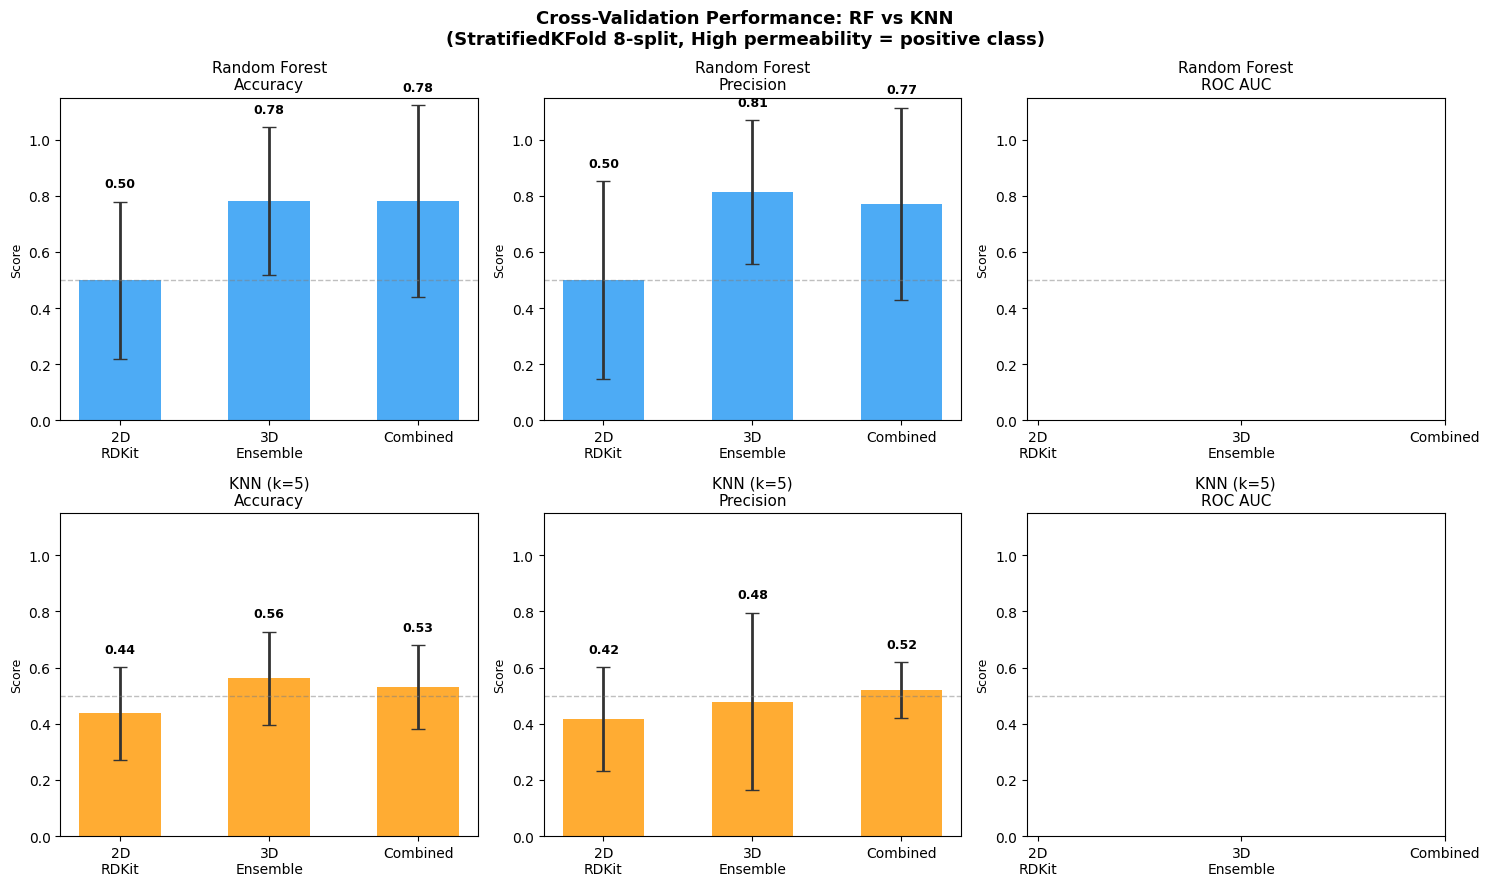

Figure saved.


In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
fig.suptitle('Cross-Validation Performance: RF vs KNN\n'
             '(StratifiedKFold 8-split, High permeability = positive class)',
             fontsize=13, fontweight='bold')

metrics_display = ['accuracy', 'precision', 'roc_auc']
metric_titles   = ['Accuracy', 'Precision', 'ROC AUC']
models          = [('Random Forest', rf_results, '#2196F3'),
                   ('KNN (k=5)',     knn_results, '#FF9800')]
fs_labels       = list(feature_sets.keys())
x               = np.arange(len(fs_labels))
width           = 0.35

for row_idx, (model_name, results, color) in enumerate(models):
    for col_idx, (metric, mtitle) in enumerate(zip(metrics_display, metric_titles)):
        ax = axes[row_idx][col_idx]
        means = [results[fs][metric][0] for fs in fs_labels]
        stds  = [results[fs][metric][1] for fs in fs_labels]
        bars = ax.bar(x, means, yerr=stds, capsize=5,
                      color=[color]*3, alpha=0.8, width=0.55,
                      error_kw={'elinewidth':2, 'ecolor':'#333'})
        ax.set_xticks(x)
        ax.set_xticklabels(['2D\nRDKit', '3D\nEnsemble', 'Combined'], fontsize=10)
        ax.set_ylim(0, 1.15)
        ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.5, label='Random baseline')
        ax.set_title(f'{model_name}\n{mtitle}', fontsize=11)
        ax.set_ylabel('Score', fontsize=9)
        # Annotate bars
        for bar, mean, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.04,
                    f'{mean:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

In [43]:
# Print neat summary table
print('='*78)
print('SUMMARY TABLE  (mean ± std)')
print('='*78)
print(f'{"Model":<8} {"Feature Set":<16} {"Accuracy":>18} {"Precision":>18} {"ROC AUC":>18}')
print('-'*78)
for label in fs_labels:
    m = rf_results[label]
    print(f'{"RF":<8} {label:<16} '
          f'{m["accuracy"][0]:.3f}±{m["accuracy"][1]:.3f}  '
          f'{m["precision"][0]:.3f}±{m["precision"][1]:.3f}  '
          f'{m["roc_auc"][0]:.3f}±{m["roc_auc"][1]:.3f}')
print()
for label in fs_labels:
    m = knn_results[label]
    print(f'{"KNN":<8} {label:<16} '
          f'{m["accuracy"][0]:.3f}±{m["accuracy"][1]:.3f}  '
          f'{m["precision"][0]:.3f}±{m["precision"][1]:.3f}  '
          f'{m["roc_auc"][0]:.3f}±{m["roc_auc"][1]:.3f}')
print('='*78)


SUMMARY TABLE  (mean ± std)
Model    Feature Set                Accuracy          Precision            ROC AUC
------------------------------------------------------------------------------
RF       2D RDKit         0.500±0.280  0.500±0.354  nan±nan
RF       3D Ensemble      0.781±0.263  0.812±0.256  nan±nan
RF       Combined         0.781±0.341  0.771±0.343  nan±nan

KNN      2D RDKit         0.438±0.165  0.417±0.186  nan±nan
KNN      3D Ensemble      0.562±0.165  0.479±0.317  nan±nan
KNN      Combined         0.531±0.150  0.521±0.100  nan±nan
